In [104]:
import pandas as pd
import numpy as np

In [105]:
results = pd.read_csv('../results/RNN-grid-search-results-clean')

In [106]:
results

,hidden_units,learning_rate,back_prop_steps,run_loss
0,25,0.50,0,5.016976
1,25,0.50,2,4.978069
2,25,0.50,5,4.933136
3,50,0.50,0,4.968243
4,50,0.50,2,5.027571
5,50,0.50,5,4.964726
6,25,0.10,0,5.195891
7,25,0.10,2,5.190748
8,25,0.10,5,5.209638
9,50,0.10,0,5.152268


In [107]:
results['perplexity'] = np.exp(results.run_loss)

In [108]:
results.sort_values(by='perplexity')

,hidden_units,learning_rate,back_prop_steps,run_loss,perplexity
2,25,0.50,5,4.933136,138.814193
5,50,0.50,5,4.964726,143.269290
3,50,0.50,0,4.968243,143.774107
1,25,0.50,2,4.978069,145.193775
0,25,0.50,0,5.016976,150.954107
4,50,0.50,2,5.027571,152.561928
10,50,0.10,2,5.123840,167.979173
11,50,0.10,5,5.140868,170.863994
9,50,0.10,0,5.152268,172.823009
7,25,0.10,2,5.190748,179.602875


Learning rate has the biggest effect on performance: all runs with learning rate 0.5 perform better than those with learning rate 0.1, and the latter better than those with learning rate 0.05. This could be because of the limited number of epochs - in no cases was training long enough for convergence, and lower learning rates converge slower. Should also note that annealing was present for all runs, meaning that a low initial learning rate became extremely low in later epochs. When learning rate was low, less backpropagation generally led to better results, when it was moderate, a moderate amount of backpropagation led to better results, and when it was high, a high amount of backpropagation led to best results. In general a higher dimensional hidden state led to better performance if other factors were the same, although the best hyperparameter set used the smaller hidden state.

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context('talk')

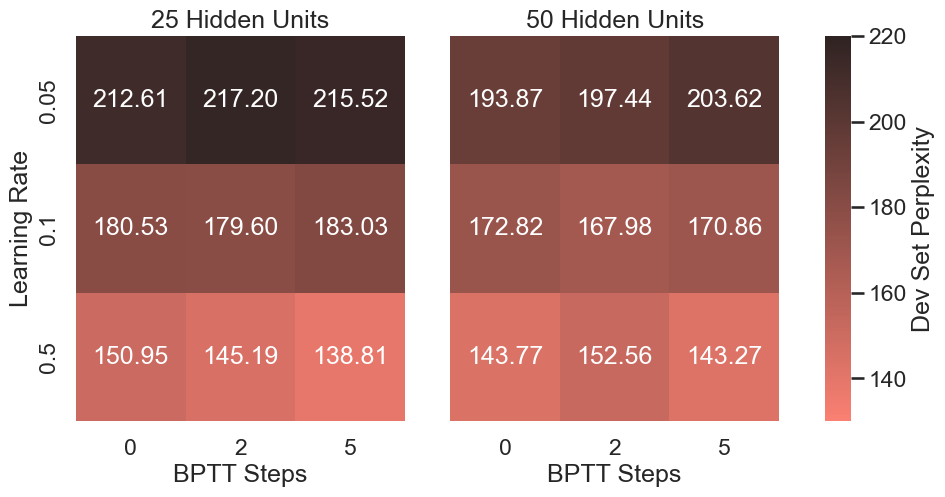

In [110]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 5), gridspec_kw={'width_ratios':[1,1,0.08]})

sns.heatmap(results[results.hidden_units==25].pivot_table(index="learning_rate", columns="back_prop_steps", values="perplexity"), cmap=sns.dark_palette("salmon", as_cmap=True, reverse=True), annot=True, fmt=".2f", vmin=130, vmax=220, ax=axs[0], cbar=False)
sns.heatmap(results[results.hidden_units==50].pivot_table(index="learning_rate", columns="back_prop_steps", values="perplexity"), cmap=sns.dark_palette("salmon", reverse=True, as_cmap=True)
, annot=True, fmt=".2f", vmin=130, vmax=220, ax=axs[1], cbar_ax=axs[2], cbar_kws={'label': 'Dev Set Perplexity'})

axs[0].set_ylabel('Learning Rate')
axs[1].set_ylabel("")
axs[1].set_yticks([])
axs[0].set_xlabel("BPTT Steps")
axs[1].set_xlabel("BPTT Steps")
axs[0].set_title("25 Hidden Units")
axs[1].set_title("50 Hidden Units")

plt.show()